In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

players = pd.read_csv('/content/drive/MyDrive/datasets/players_cleaned_of_mobile_game_inapp_purchases.csv')
purchases = pd.read_csv('/content/drive/MyDrive/datasets/purchase_cleaned.csv')

print("Players loaded:", players.shape)
print("Purchases loaded:", purchases.shape)

Players loaded: (3024, 18)
Purchases loaded: (2887, 10)


In [39]:
players[['session_count',
         'avg_session_length',
         'total_play_mins',
         'in_app_purchase_amount']].corr()

,session_count,avg_session_length,total_play_mins,in_app_purchase_amount
session_count,1.000000,-0.010563,0.564974,0.034932
avg_session_length,-0.010563,1.000000,0.780952,-0.027899
total_play_mins,0.564974,0.780952,1.000000,0.001324
in_app_purchase_amount,0.034932,-0.027899,0.001324,1.000000


In [40]:
players.groupby('spending_segment')[
    ['session_count',
     'avg_session_length',
     'total_play_mins',
     'in_app_purchase_amount']
].mean()

,session_count,avg_session_length,total_play_mins,in_app_purchase_amount
spending_segment,,,,
Dolphin,10.123786,20.035704,202.517743,233.71068
Minnow,10.044025,20.137445,201.958404,9.58623
Whale,10.926471,17.931471,198.531618,2582.10500


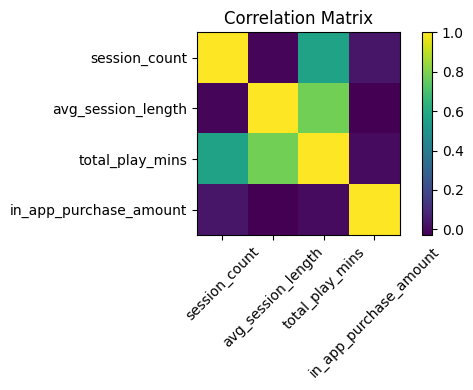

In [41]:
import matplotlib.pyplot as plt

corr = players[['session_count',
                'avg_session_length',
                'total_play_mins',
                'in_app_purchase_amount']].corr()

plt.figure(figsize=(6,4))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

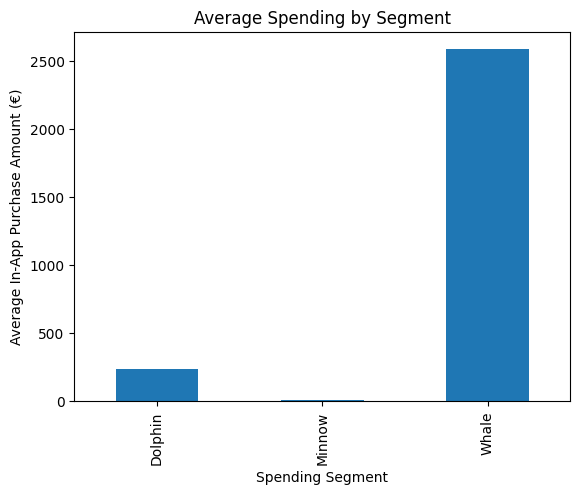

In [42]:
segment_avg = players.groupby('spending_segment')[
    'in_app_purchase_amount'
].mean()

segment_avg.plot(kind='bar')

plt.title('Average Spending by Segment')
plt.xlabel('Spending Segment')
plt.ylabel('Average In-App Purchase Amount (€)')

plt.show()